# TP2 Apprentissage supervisé

In [1]:
#importation des packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("Donnees_qualite_vin.csv", sep=';')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [3]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## Summary  analysis of the table

In [4]:
data.shape

(1599, 12)

In [5]:
data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [6]:
var_exp=data.drop(columns='quality')
var_exp.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [7]:
data['quality'].value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

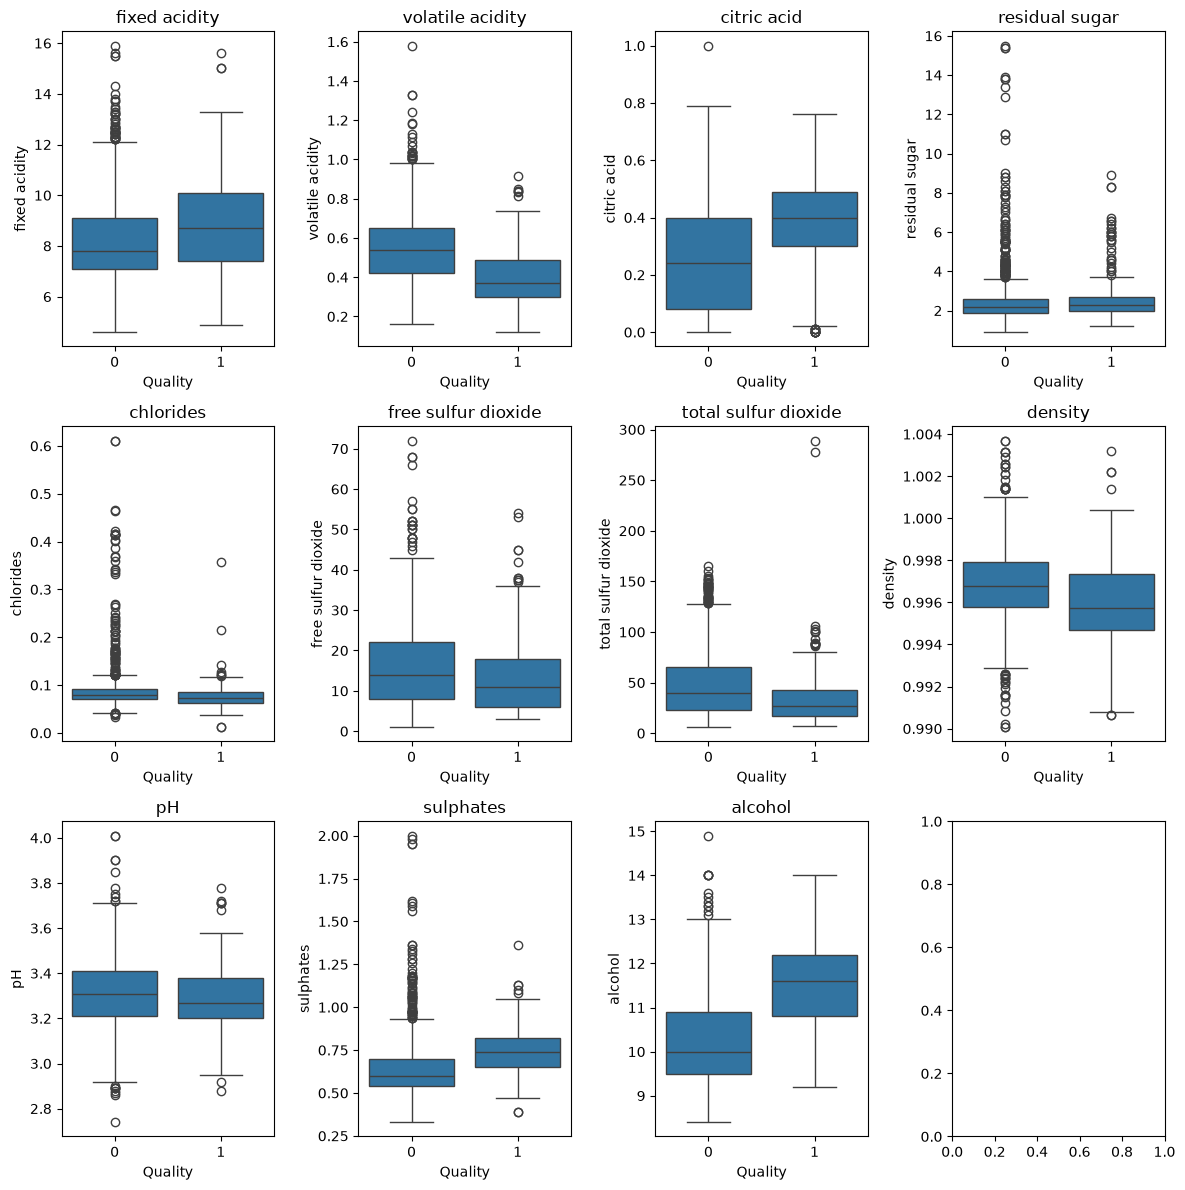

In [8]:
ncols=4
nrows=3
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(12, 4 * nrows)
)

for ax, variable in zip(axes.flatten(), var_exp):
    sns.boxplot(data=data, x="quality", y=variable, ax=ax)
    ax.set_title(f"{variable}")
    ax.set_xlabel("Quality")
    ax.set_ylabel(variable)

plt.tight_layout()
plt.show()

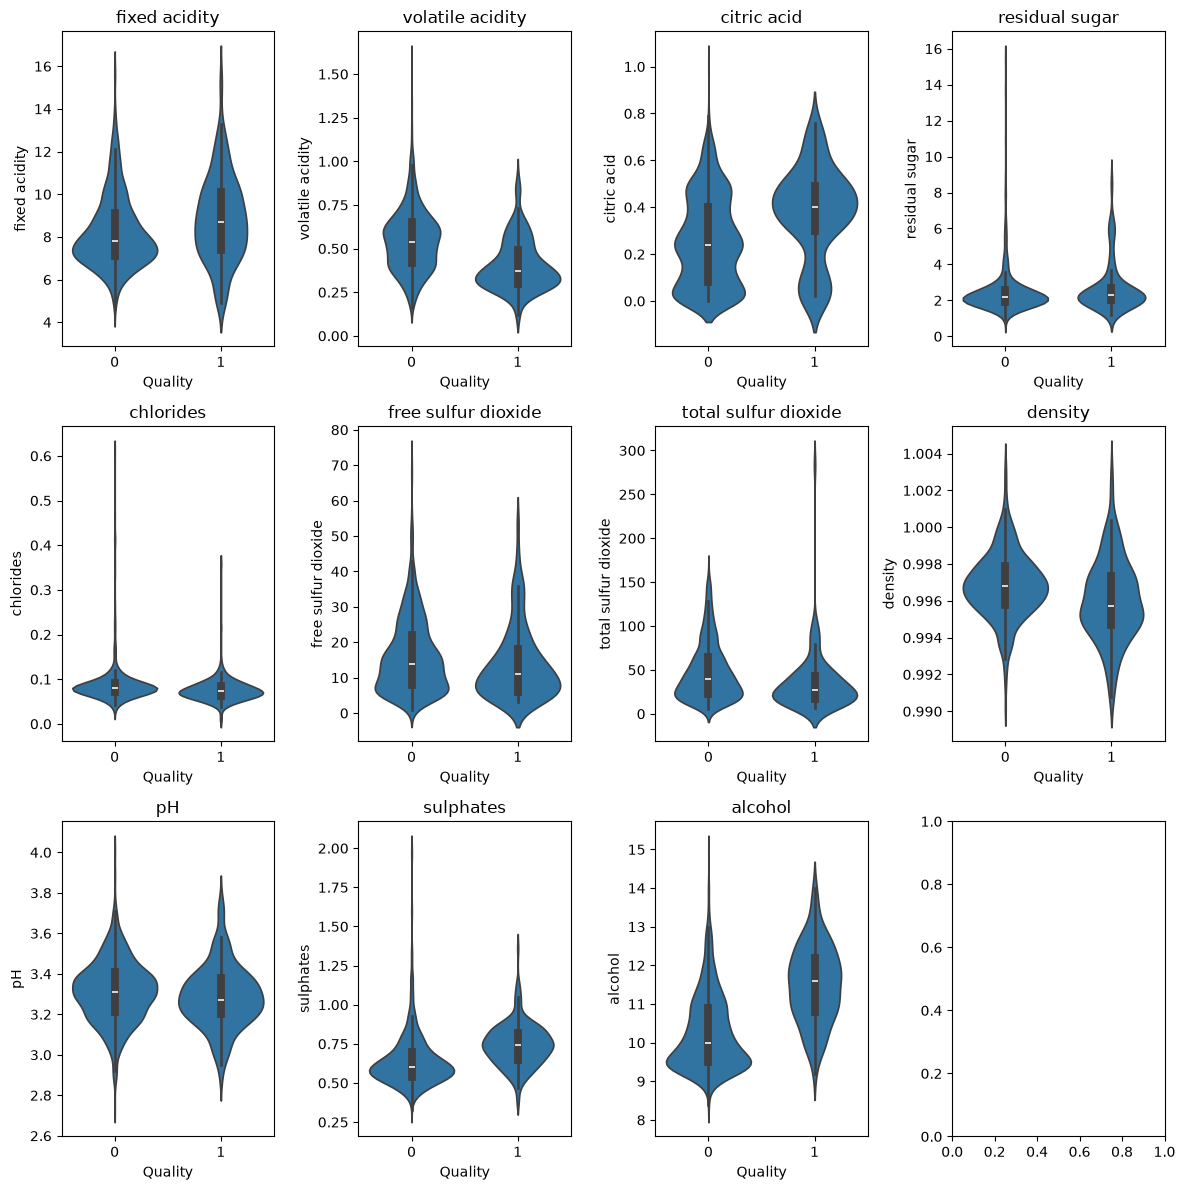

In [9]:
ncols=4
nrows=3
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(12, 4 * nrows)
)

for ax, variable in zip(axes.flatten(), var_exp):
    sns.violinplot(data=data,
     x="quality", 
     y=variable, 
     ax=ax)
    ax.set_title(f"{variable}")
    ax.set_xlabel("Quality")
    ax.set_ylabel(variable)

plt.tight_layout()
plt.show()

##### CONCLUSION
Il y a des variables qui sont plus influentes que les autres. Donc on ne va pas utiliser toutes les variables. 
La classe "quality" est déséquilibrée. 

## Partie 2

##### 1) création des échantillons

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X=data.drop(columns="quality")
Y=data["quality"]

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y   ##Echantillonage stratifié
)

## 1) Naive Bayes
On doit utiliser la méthode des n oyaux. Et on doit donc  estimer la **largeur de la bande** (hyperparamètre 1)

#### choix de l'hyperparamètre
Il faut noter que dans la question précédente, on a demandé de diviser les données en train et test. 
Donc on doit utiliser que soit cross validation, soit monte carlo. Mais en général, on prime sur cross validation.

In [27]:
#création de la classe KernelNaiveBayes

from sklearn.base import BaseEstimator, ClassifierMixin

class KernelNaiveBayes(BaseEstimator,ClassifierMixin):

    def __init__(self, usekernel=True, fL=0.1, adjust=1.0):
        self.userkernel=usekernel
        self.fL=fL
        self.adjust=adjust

def fit(self, X, Y):
    #prediction
    self.classes_=np.unique(Y)
    return self

In [26]:
#usekernel, fL et adjust
from sklearn.model_selection import ParameterGrid

param_grid = {
    "usekernel": [True, False],
    "fL": [0.6, 0.8, 1.0],
    "adjust": [0.5, 1.0, 1.5, 2.0]
}

grid=ParameterGrid(param_grid)
print("Nombre de combinaisons:", len(grid))

Nombre de combinaisons: 24


#### **Cross validation**



In [ ]:
#cross validation sur train
from sklearn. model_selection import GridSearchCV

grid_search=GridSearchCV(
    KernelNaiveBayes(),
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

In [23]:
print(grid_search.best_params_)

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:

from sklearn.naive_bayes import GaussianNB

##Création du modèle Naive Bayes
model=GaussianNB()

#on entraîne le modèle
model.fit(X_train,Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[221., 35.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.86,0.14]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,8.823e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[ 8.01, 0.55, 0.24,..., 3.32, 0.63,10.25], [ 8.88, 0.41, 0.37,..., 3.28, 0.74,11.35]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[2.35,0.03,0.03,...,0.03,0.03,0.99], [3.18,0.01,0.03,...,0.02,0.01,0.8 ]]"


In [ ]:
#Prédiction avec Naive Bayes
y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,

In [ ]:
#Evaluation du modèle
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

print("Métrique d'évaluation du modèle")
print('-----------------------------------------------------------')
#Accuracy
accuracy=accuracy_score(Y_test,y_pred)
print("accuracy:",accuracy)
print('-----------------------------------------------------------')

#Matrice de confusion
matrice_de_confusion=confusion_matrix(Y_test,y_pred)
print("matrice de confusion")
print(matrice_de_confusion)
print('-----------------------------------------------------------')

#Voir toutes les métriques
print("Résumé de toutes le métriques")
print(classification_report(Y_test,y_pred))
print('-----------------------------------------------------------')


Métrique d'évaluation du modèle
-----------------------------------------------------------
accuracy: 0.865625
-----------------------------------------------------------
matrice de confusion
[[246  31]
 [ 12  31]]
-----------------------------------------------------------
Résumé de toutes le métriques
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       277
           1       0.50      0.72      0.59        43

    accuracy                           0.87       320
   macro avg       0.73      0.80      0.76       320
weighted avg       0.89      0.87      0.88       320

-----------------------------------------------------------


In [ ]:
Y_test.value_counts()

quality
0    277
1     43
Name: count, dtype: int64

##  COMMENTAIRE
 #### Precision
Parmi les observations que le classifieur naïf de Bays a classé dans la classe 1, seulement 50% appartiennent réellement à la classe 1. **Mauvais**
 Mais, , parmi les observations que le classifieur naïf de Bays a classé dans la classe 0, 95% appartiennent réellement à la classe 1. **bon**

 #### Recall
Parmi les 277 individus qui sont réellement dans la classe 0, le modèle a réussi à trouver 89%.
Parmi les 43 qui sont réellement dans la classe 1, il réussi à en trouver 72%.

#### Accuracy (peut être trompeuse en cas de déséquilibre dans les classes)
En général, le modèle classe correctement 87% des observations. 